In [17]:
import os
import json
import time
import cryo
from dotenv import load_dotenv
import pandas as pd
import polars as pl
from web3 import Web3

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from io import StringIO

curr_dir = os.getcwd()
parent_dir = os.path.dirname(curr_dir)
# Load the environment variables
dotenv_path = os.path.join(parent_dir, 'env_variables', '.env')
load_dotenv(dotenv_path)

# Retrieve the Ethereum RPC URL from environment variables
ETH_RPC_NAME = "ETH_RPC"
eth_rpc = os.getenv(ETH_RPC_NAME)
# check that the RPC URL is set
if eth_rpc is None:
    raise ValueError("ETH_RPC is not set in the .env file")
else:
    print(f'Env variable {ETH_RPC_NAME} loaded.')

# TEST OF THE RPC URL WITH web3
web3 = Web3(Web3.HTTPProvider(eth_rpc))
if web3.is_connected():
    print("Connected to Ethereum node")
else:
    raise ValueError("Could not connect to Ethereum node")

# test a simple cryo query
try:
    data = cryo.collect("blocks", blocks=["21782280:21782281"], rpc=eth_rpc, output_format="pandas", hex=True)
    print('Cryo (collect) query successful')
except Exception as e:    
    print(f'cryo query failed: {e}')

Env variable ETH_RPC loaded.
Connected to Ethereum node
Cryo query successful


### I) Top 10 block authors ( cryo.collect() ) 

In [ ]:
# Constants
ETH_RPC_VAR = "ETH_RPC"
LOOKBACK_BLOCKS = 5000
TOP_AUTHORS_COUNT = 10

# Function to get the block range
def get_block_range(web3, lookback_blocks):
    latest_block = web3.eth.block_number
    start_block = max(0, latest_block - lookback_blocks)  # Avoid negative block numbers
    return f"{start_block}:{latest_block}"

# Function to fetch data from cryo
def fetch_block_data(block_range, eth_rpc):
    try:
        # Start timer for fetching blocks
        fetch_start_time = time.time()

        # Fetch the block data
        data = cryo.collect(
            "blocks", blocks=[block_range], rpc=eth_rpc, output_format="pandas", hex=True
        )

        # Calculate and print the time taken to fetch the blocks
        fetch_time = time.time() - fetch_start_time
        print(f"Time taken to fetch blocks: {fetch_time:.2f} seconds")
        return data
    except Exception as e:
        print(f"An error occurred while fetching block data: {e}")
        return pd.DataFrame()  # Return an empty DataFrame on error

# Function to plot the top authors
def plot_top_authors(data, num_entries):
    top_authors = data['author'].value_counts().head(TOP_AUTHORS_COUNT)
    plt.figure(figsize=(12, 6))
    top_authors.plot(kind='bar')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top {TOP_AUTHORS_COUNT} Authors by number of blocks mined from past {num_entries} blocks', fontsize=14)
    plt.xlabel('Author', fontsize=14)
    plt.ylabel('Number of Blocks', fontsize=14)
    plt.tight_layout()
    plt.show()

# Main execution
def main():
    eth_rpc = os.getenv(ETH_RPC_VAR)
    if not eth_rpc:
        raise ValueError(f"Environment variable {ETH_RPC_VAR} not found")

    w3 = Web3(Web3.HTTPProvider(eth_rpc))
    if not w3.is_connected():
        print("Failed to connect to Ethereum node.")
        return

    block_range = get_block_range(w3, LOOKBACK_BLOCKS)
    print(f"Fetching blocks from {block_range} range.")
    
    data = fetch_block_data(block_range, eth_rpc)
    if not data.empty:
        num_entries = len(data)
        print(f"Number of blocks fetched: {num_entries}")
        plot_top_authors(data, num_entries)

main()

### II) TOKEN BALANCE CHANGE

Data fetched in 12.51 seconds.

Data summary:
Block rage: 21780688:21782488
Start balance in Ether: 2298.408192439029225962
End balance in Ether: 2233.290887324332332737


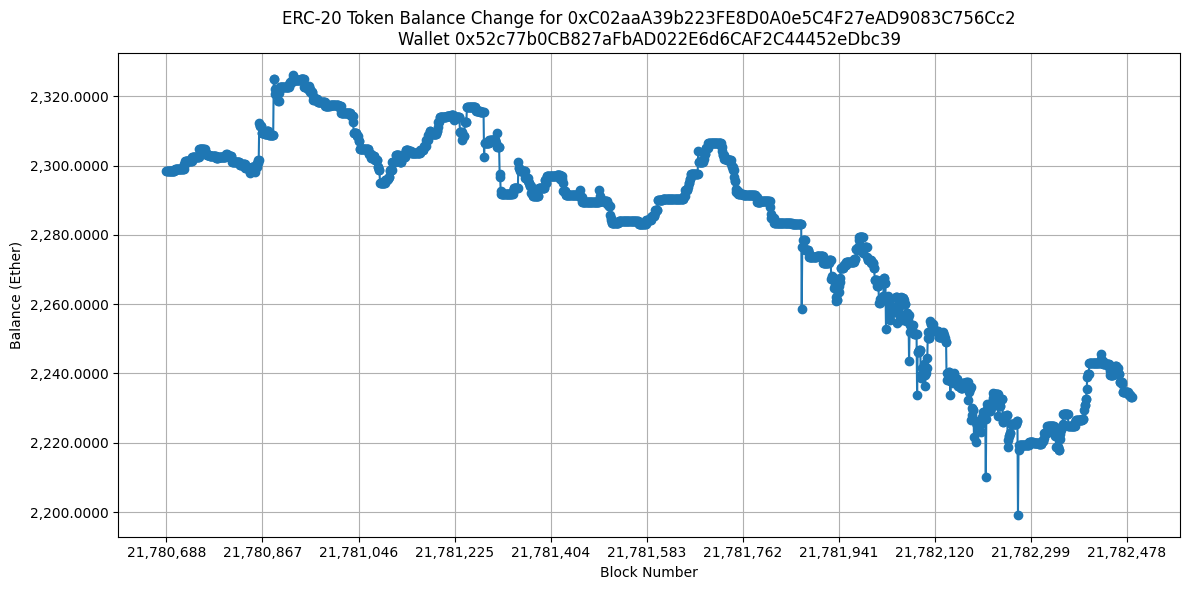

In [ ]:
# Constants
ETH_RPC_VAR = "ETH_RPC"
LOOKBACK_BLOCKS = int(7200/4) # 7200 is approx a day in the past
CONTRACT_ADDRESS = '0xC02aaA39b223FE8D0A0e5C4F27eAD9083C756Cc2' # WETH
# WALLET_ADDRESS = '0x0d4a11d5EEaaC28EC3F61d100daF4d40471f1852'   # WETH-USDT pool Uniswap V2
WALLET_ADDRESS = '0x52c77b0CB827aFbAD022E6d6CAF2C44452eDbc39' # SP69000 WETH-SP69000 pool Uniswap 


def check_eth_rpc_connection(eth_rpc):
    """Check connection to Ethereum RPC."""
    if not eth_rpc:
        raise ValueError(f"Environment variable {ETH_RPC_VAR} not found")
    if not web3.is_connected():
        raise ConnectionError("Failed to connect to Ethereum node.")

def get_block_range(lookback_blocks):
    #TODO add a tickrate for the block to have them every X blocks
    """Determine the range of blocks to fetch."""
    latest_block = web3.eth.block_number
    start_block = max(0, latest_block - lookback_blocks)
    return f"{start_block}:{latest_block}"

def fetch_erc20_balances(block_range):
    """Fetch ERC-20 token balances within a given block range."""
    return cryo.collect(
        "erc20_balances",
        blocks=[block_range],
        contract=[CONTRACT_ADDRESS],
        address=[WALLET_ADDRESS],
        rpc=eth_rpc,
        output_format="pandas",
        hex=True,
        requests_per_second=250 # Adapt the RPS to your endpoint
    )

def convert_balance_to_ether(balance_str):
    """Convert balance from Wei to Ether, handling None values."""
    return None if balance_str is None else Web3.from_wei(int(balance_str), 'ether')

def plot_balance_change_over_time(data):
    """Plot the balance change over time on a chart."""
    plt.figure(figsize=(12, 6))
    plt.plot(data['block_number'], data['balance_ether'], marker='o')

    # Set axis labels and chart title with contract and address
    plt.xlabel("Block Number")
    plt.ylabel("Balance (Ether)")
    plt.title(f"ERC-20 Token Balance Change for {CONTRACT_ADDRESS}\nWallet {WALLET_ADDRESS}")

    # Manually set the x-axis ticks based on the block range
    block_numbers = data['block_number']
    tick_spacing = (block_numbers.max() - block_numbers.min()) // 10  # for example, 10 evenly spaced ticks
    ticks = range(int(block_numbers.min()), int(block_numbers.max()), int(tick_spacing))
    plt.xticks(ticks, [f"{tick:,.0f}" for tick in ticks])

    # Format the y-axis to show balances rounded to 4 decimal places
    plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.4f}'))

    # Add grid, tighten layout, and display the plot
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def main():
    """Main function to fetch and plot ERC-20 token balance changes."""
    check_eth_rpc_connection(eth_rpc)
    block_range = get_block_range(LOOKBACK_BLOCKS)

    # Start timing the data fetch
    start_time = time.time()

    # Fetch the data
    data = fetch_erc20_balances(block_range)

    # End timing the data fetch
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Data fetched in {elapsed_time:.2f} seconds.")

    if data.empty:
        print("No data available for plotting.")
        return
    
    # Prepare data for plotting
    data = data[['block_number', 'erc20', 'address', 'balance_string']]
    data['balance_ether'] = data['balance_string'].apply(convert_balance_to_ether)
    data = data[data['balance_ether'].notnull()]  # Filter out rows with None values

    # # Print data summary to the console
    # print("\nData summary:")
    # print(f"Block rage: {block_range}")
    # print(f"Start balance in Ether: {data.iloc[0]['balance_ether']}")
    # print(f"End balance in Ether: {data.iloc[-1]['balance_ether']}")

    # Plot the balance changes over time
    plot_balance_change_over_time(data)

main()

In [8]:
erc20_tokens = [
    "0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48",  # USDC
    "0xdac17f958d2ee523a2206206994597c13d831ec7"   # USDT
]

wallets = [
    "0x0a59649758aa4d66e25f08dd01271e891fe52199",  # Maker PSM
    "0xcee284f754e854890e311e3280b767f80797180d"   # Arbitrum Bridge
]

block_range = "16M:17M/10"  # 10 blocks between 16,000,000 and 17,000,000

# Fetch the ERC20 balances data
data = cryo.collect(
    "erc20_balances", 
    blocks=block_range, 
    contract=erc20_addresses, 
    address=wallet_addresses, 
    rpc=eth_rpc, 
    output_format="pandas")


An error occurred while fetching ERC20 balances: argument 'blocks': Can't extract `str` to `Vec`
Empty DataFrame
Columns: []
Index: []
